In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/)
# Temporary files can go to /kaggle/temp/ but won't be saved outside the session

# GEARS benchmark — Norman dataset

Evaluates GEARS against an average-of-singles baseline on the **Norman** double-gene perturbation dataset.

**Dataset:** ~89 400 cells · 5 045 genes · 148 single-gene + 128 double-gene perturbations  
**Task:** predict gene expression for double-gene perturbations where **both** component genes were seen in training (the "combo_seen2" setting)  
**Split:** 138 singles for training, 10 for validation, 124 2-seen doubles for test

**Baseline:** for each double perturbation A+B, predict the average of the single-gene centroids for A and B.

| Metric | Description |
|---|---|
| RMSE (raw) | RMSE on absolute expression |
| Pearson (raw) | Pearson r on absolute expression |
| Pearson (delta) | Pearson r on expression change relative to training mean |
| Centroid accuracy | Nearest-centroid ranking accuracy across test perturbations |

## 1 · Environment setup

In [1]:
%%capture
# Install required packages (output suppressed)
!pip install -q scanpy python-igraph louvain
!pip install -q torch-geometric anndata pytorch-lightning
!pip install -q cell-gears


In [2]:
import numpy as np
import pandas as pd
import torch
from scipy import sparse
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Compatibility patch required by some GEARS versions
pd.Series.nonzero = lambda self: self.to_numpy().nonzero()

from gears import PertData, GEARS

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | GPU available: {torch.cuda.is_available()} | device: {DEVICE}")

PyTorch 2.5.1+cu118 | GPU available: True | device: cuda


## 2 · Load data

In [3]:
%%capture
pert_data = PertData('./data')
pert_data.load(data_name='norman')

In [4]:
adata = pert_data.adata
print(adata)


def normalize(p):
    """Canonicalise condition names: sort genes, put ctrl last."""
    p = str(p)
    if p == "ctrl":
        return "ctrl"
    parts = sorted(p.split("+"))
    if "ctrl" in parts:
        gene = [x for x in parts if x != "ctrl"][0]
        return gene + "+ctrl"
    return "+".join(parts)


def get_genes(p):
    """Return the non-ctrl gene(s) from a condition name."""
    p = str(p)
    if p == "ctrl":
        return []
    return [g for g in p.split("+") if g != "ctrl"]


adata.obs["condition_orig"] = adata.obs["condition"].astype(str)
adata.obs["condition_norm"] = adata.obs["condition_orig"].apply(normalize)

View of AnnData object with n_obs × n_vars = 89357 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'


## 3 · Split perturbations into singles and doubles

In [5]:
rows = adata.obs[["condition_orig", "condition_norm"]].drop_duplicates()

single_perts = rows[
    rows["condition_norm"].apply(lambda p: len(get_genes(p)) == 1)
]["condition_orig"].tolist()

double_perts = rows[
    rows["condition_norm"].apply(lambda p: len(get_genes(p)) == 2)
]["condition_orig"].tolist()

print(f"Single-gene perturbations: {len(single_perts)}")
print(f"Double-gene perturbations: {len(double_perts)}")

Single-gene perturbations: 148
Double-gene perturbations: 128


## 4 · Train / val / test split

The test set contains only **combo_seen2** perturbations: doubles where both component genes appear in training.

In [6]:
all_train_singles = single_perts.copy()
np.random.seed(1)
np.random.shuffle(all_train_singles)

val_perts   = all_train_singles[:10]
train_perts = all_train_singles[10:]

train_genes = {get_genes(normalize(p))[0] for p in train_perts}

# Keep only doubles whose both genes were seen in training
test_perts = [
    p for p in double_perts
    if set(get_genes(normalize(p))).issubset(train_genes)
]

print(f"Train singles: {len(train_perts)} | Val singles: {len(val_perts)} | Test doubles (2-seen): {len(test_perts)}")

Train singles: 138 | Val singles: 10 | Test doubles (2-seen): 124


In [7]:
%%capture
pert_data.prepare_split(split="simulation", seed=1)

pert_data.set2conditions = {"train": train_perts, "val": val_perts, "test": test_perts}
pert_data.subgroup       = {"test_subgroup": {"combo_seen2": test_perts}}
pert_data.train_perts    = train_perts
pert_data.val_perts      = val_perts
pert_data.test_perts     = test_perts

In [8]:
# Sanity check: all test perturbations must be 2-seen
train_genes_check = set()
for p in train_perts:
    train_genes_check.update(get_genes(normalize(p)))

for p in test_perts:
    genes = set(get_genes(normalize(p)))
    assert genes.issubset(train_genes_check), f"NOT 2-seen: {p}"

print("All test perturbations verified as 2-seen")

All test perturbations verified as 2-seen


In [9]:
%%capture
pert_data.get_dataloader(batch_size=32, test_batch_size=128)

## 5 · Train GEARS

In [10]:
%%capture
model = GEARS(pert_data, device=DEVICE)
model.model_initialize(hidden_size=64)
model.train(epochs=20)
print("Training complete")

## 6 · Predict on test perturbations

In [11]:
pred_input = [get_genes(normalize(p)) for p in test_perts]
pred_res   = model.predict(pred_input)
print(f"Predictions received for {len(pred_res)} perturbations")

Predictions received for 124 perturbations


## 7 · Build centroids and evaluate

In [12]:
def to_numpy(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def safe_pearson(y_pred, y_true):
    y_pred, y_true = np.asarray(y_pred), np.asarray(y_true)
    if np.std(y_pred) == 0 or np.std(y_true) == 0:
        return np.nan
    return pearsonr(y_pred, y_true)[0]


def rmse(y_pred, y_true):
    return float(np.sqrt(np.mean((np.asarray(y_pred) - np.asarray(y_true)) ** 2)))


def centroid_accuracy(pred_dict, truth_dict):
    """Nearest-centroid ranking accuracy across test perturbations."""
    perts = [p for p in pred_dict if p in truth_dict]
    scores = []
    for p in perts:
        d_correct = np.linalg.norm(np.asarray(pred_dict[p]) - np.asarray(truth_dict[p]))
        d_others  = [
            np.linalg.norm(np.asarray(pred_dict[p]) - np.asarray(truth_dict[q]))
            for q in perts if q != p
        ]
        if d_others:
            scores.append(np.mean([d_correct < d for d in d_others]))
    return float(np.mean(scores))


# ── Normalise GEARS prediction keys ──────────────────────────────────────────
pred_centroids = {}
for k, v in pred_res.items():
    key = normalize(k.replace("_", "+"))
    arr = np.asarray(v)
    pred_centroids[key] = arr.mean(axis=0) if arr.ndim == 2 else arr


# ── Ground-truth centroids for test perturbations ─────────────────────────────
cond_vals = adata.obs["condition"].astype(str).values
truth_dict = {}
for p in test_perts:
    mask = cond_vals == p
    Xp = to_numpy(adata.X[mask])
    if Xp.shape[0] > 0:
        truth_dict[normalize(p)] = Xp.mean(axis=0)


# ── Single-gene centroids (training) for baseline ────────────────────────────
single_centroids = {}
for p in train_perts:
    key = normalize(p)
    genes = get_genes(key)
    if len(genes) != 1:
        continue
    mask = cond_vals == p
    Xp = to_numpy(adata.X[mask])
    if Xp.shape[0] > 0:
        single_centroids[genes[0]] = Xp.mean(axis=0)

# Average baseline: (centroid_A + centroid_B) / 2
avg_pred_centroids = {}
for p in test_perts:
    key = normalize(p)
    g1, g2 = get_genes(key)
    if g1 in single_centroids and g2 in single_centroids:
        avg_pred_centroids[key] = (single_centroids[g1] + single_centroids[g2]) / 2


# ── Reference vector: mean of all training perturbations ─────────────────────
train_masks = [cond_vals == p for p in train_perts if normalize(p) != "ctrl"]
train_mask  = np.any(train_masks, axis=0)
reference   = to_numpy(adata.X[train_mask]).mean(axis=0)


# ── Restrict to perturbations present in all three dicts ─────────────────────
common = set(pred_centroids) & set(avg_pred_centroids) & set(truth_dict)
print(f"Common perturbations: {len(common)}")

pred_f = {p: pred_centroids[p]     for p in common}
avg_f  = {p: avg_pred_centroids[p] for p in common}
true_f = {p: truth_dict[p]         for p in common}


# ── Per-perturbation scores ───────────────────────────────────────────────────
rows = []
for p in common:
    y_true   = np.asarray(true_f[p])
    y_gears  = np.asarray(pred_f[p])
    y_avg    = np.asarray(avg_f[p])

    true_delta  = y_true  - reference
    gears_delta = y_gears - reference
    avg_delta   = y_avg   - reference

    rows.append({
        "perturbation":         p,
        "gears_rmse_raw":       rmse(y_gears, y_true),
        "avg_rmse_raw":         rmse(y_avg,   y_true),
        "gears_pearson_raw":    safe_pearson(y_gears, y_true),
        "avg_pearson_raw":      safe_pearson(y_avg,   y_true),
        "gears_pearson_delta":  safe_pearson(gears_delta, true_delta),
        "avg_pearson_delta":    safe_pearson(avg_delta,   true_delta),
    })

results_df = pd.DataFrame(rows)


# ── Aggregate summary ─────────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    "GEARS": [
        results_df["gears_rmse_raw"].mean(),
        results_df["gears_pearson_raw"].mean(),
        results_df["gears_pearson_delta"].mean(),
        centroid_accuracy(pred_f, true_f),
    ],
    "Average prediction baseline": [
        results_df["avg_rmse_raw"].mean(),
        results_df["avg_pearson_raw"].mean(),
        results_df["avg_pearson_delta"].mean(),
        centroid_accuracy(avg_f, true_f),
    ],
}, index=["RMSE (raw)", "Pearson (raw)", "Pearson (delta)", "Centroid accuracy"])

print("=== Per-perturbation results ===")
display(results_df.set_index("perturbation").round(4))
print("\n=== Aggregate summary ===")
display(summary_df.round(4))

Common perturbations: 124


=== Per-perturbation results ===


,gears_rmse_raw,avg_rmse_raw,gears_pearson_raw,avg_pearson_raw,gears_pearson_delta,avg_pearson_delta
perturbation,,,,,,
KLF1+MAP2K6,0.0397,0.0256,0.9956,0.9981,0.7737,0.9164
ELMSAN1+LHX1,0.0586,0.0364,0.9894,0.9960,0.1170,0.7690
CLDN6+KLF1,0.0608,0.0501,0.9889,0.9925,0.6478,0.8335
ELMSAN1+ZBTB10,0.0743,0.0613,0.9828,0.9885,0.3756,0.7789
SAMD1+UBASH3B,0.0505,0.0460,0.9928,0.9934,0.6832,0.8091
...,...,...,...,...,...,...
FOXF1+HOXB9,0.0565,0.0475,0.9906,0.9931,0.4501,0.6935
CEBPE+PTPN12,0.0751,0.0251,0.9847,0.9980,0.3787,0.7810
CEBPE+FOSB,0.0720,0.0788,0.9868,0.9816,0.8703,0.8668



=== Aggregate summary ===


,GEARS,Average prediction baseline
RMSE (raw),0.0625,0.0452
Pearson (raw),0.9880,0.9926
Pearson (delta),0.5152,0.7949
Centroid accuracy,0.8392,0.8587


## 8 · Per-perturbation centroid accuracy

In [13]:
def per_pert_centroid_accuracy(pred_dict, truth_dict):
    perts = [p for p in pred_dict if p in truth_dict]
    rows  = []
    for p in perts:
        d_correct = np.linalg.norm(np.asarray(pred_dict[p]) - np.asarray(truth_dict[p]))
        d_others  = [
            np.linalg.norm(np.asarray(pred_dict[p]) - np.asarray(truth_dict[q]))
            for q in perts if q != p
        ]
        if d_others:
            rows.append({"perturbation": p,
                         "centroid_accuracy": float(np.mean([d_correct < d for d in d_others]))})
    return pd.DataFrame(rows)


centroid_table = (
    per_pert_centroid_accuracy(pred_f, true_f)
    .rename(columns={"centroid_accuracy": "gears_centroid_accuracy"})
    .merge(
        per_pert_centroid_accuracy(avg_f, true_f)
        .rename(columns={"centroid_accuracy": "avg_centroid_accuracy"}),
        on="perturbation", how="inner"
    )
)

display(centroid_table.set_index("perturbation").round(4).head(15))

,gears_centroid_accuracy,avg_centroid_accuracy
perturbation,,
KLF1+MAP2K6,1.0000,1.0000
ELMSAN1+LHX1,0.7642,0.9919
CLDN6+KLF1,0.7317,0.8943
ELMSAN1+ZBTB10,0.5041,0.6423
SAMD1+UBASH3B,0.9675,0.8699
CBFA2T3+POU3F2,0.8537,0.8455
OSR2+UBASH3B,0.9919,1.0000
IKZF3+MAP2K6,0.8211,0.9593
ELMSAN1+MAP2K6,0.9756,0.9919


## 9 · Visualisation

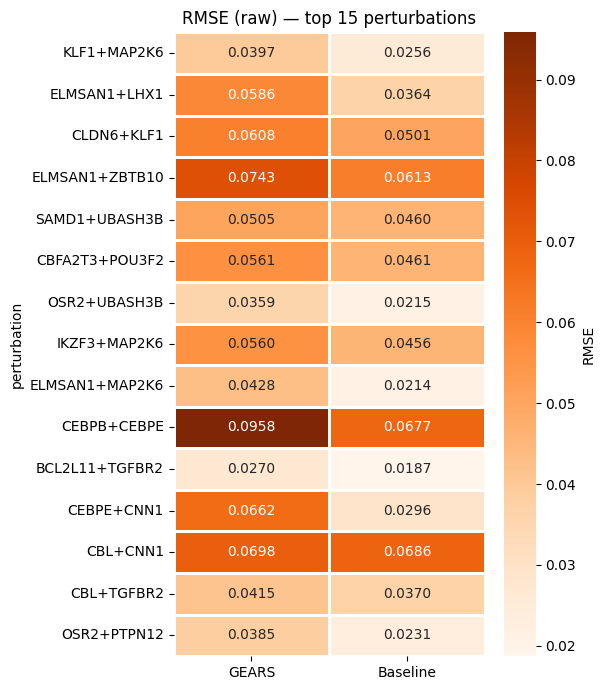

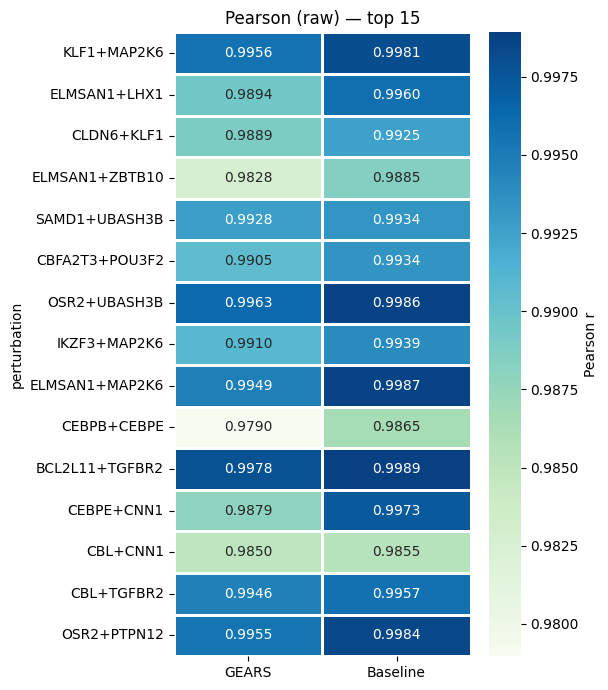

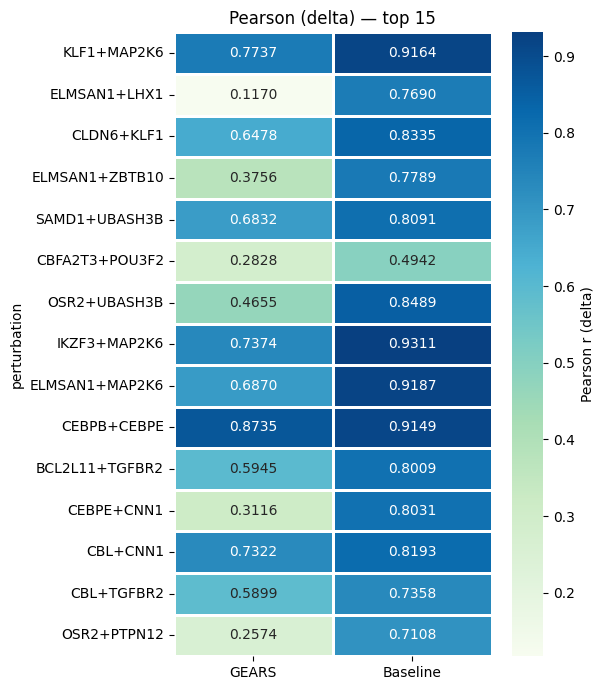

In [14]:
def heatmap(data, title, cmap, cbar_label, figsize=(6, 7)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(data, annot=True, fmt=".4f", cmap=cmap,
                linewidths=2, linecolor="white",
                cbar_kws={"label": cbar_label}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()


top15 = results_df.head(15).set_index("perturbation")

heatmap(
    top15[["gears_rmse_raw", "avg_rmse_raw"]].rename(
        columns={"gears_rmse_raw": "GEARS", "avg_rmse_raw": "Baseline"}),
    title="RMSE (raw) — top 15 perturbations",
    cmap="Oranges", cbar_label="RMSE"
)

heatmap(
    top15[["gears_pearson_raw", "avg_pearson_raw"]].rename(
        columns={"gears_pearson_raw": "GEARS", "avg_pearson_raw": "Baseline"}),
    title="Pearson (raw) — top 15",
    cmap="GnBu", cbar_label="Pearson r"
)

heatmap(
    top15[["gears_pearson_delta", "avg_pearson_delta"]].rename(
        columns={"gears_pearson_delta": "GEARS", "avg_pearson_delta": "Baseline"}),
    title="Pearson (delta) — top 15",
    cmap="GnBu", cbar_label="Pearson r (delta)"
)

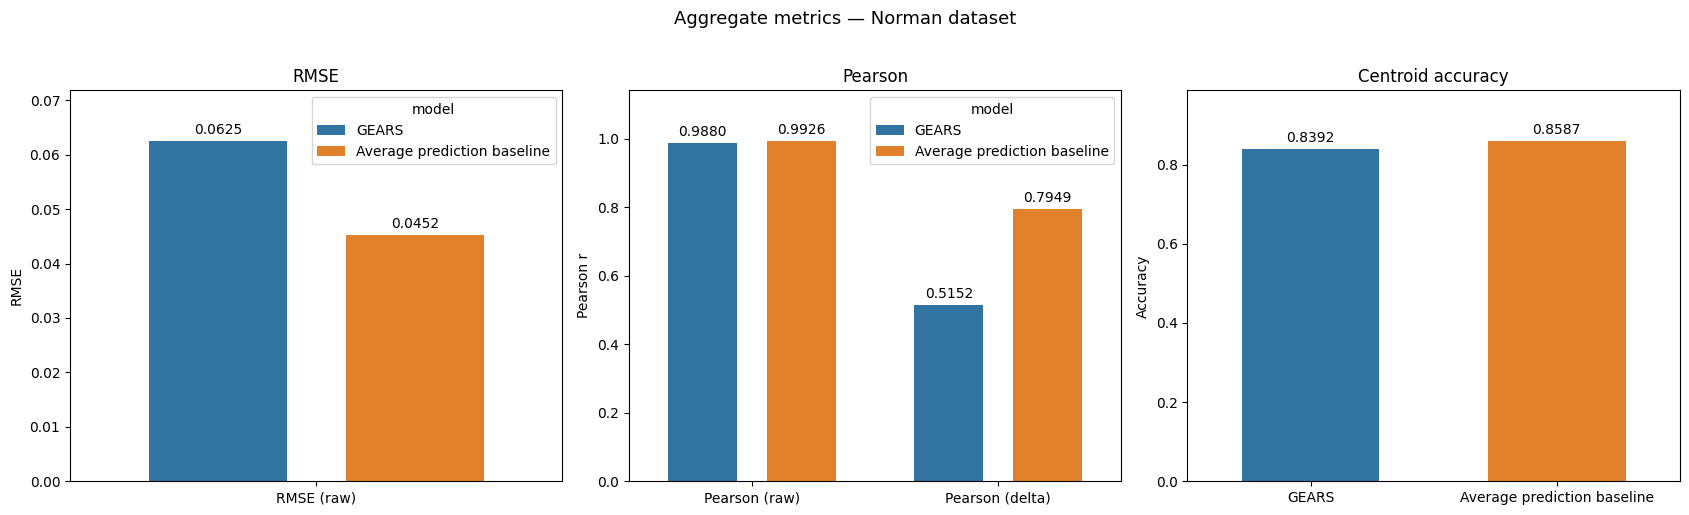

In [15]:
PALETTE = {"GEARS": "#1f77b4", "Average prediction baseline": "#ff7f0e"}

def slim_barplot(ax, data, x, y, hue, palette, title, ylabel):
    sns.barplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax)
    for bar in ax.patches:
        w = bar.get_width()
        bar.set_width(w * 0.7)
        bar.set_x(bar.get_x() + w * 0.15)
    ymax = data[y].dropna().max()
    ax.set_ylim(0, ymax * 1.15)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.4f", padding=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")


# Melt summary for grouped barplots
summary_long = summary_df.T.reset_index().rename(columns={"index": "model"})

# RMSE grouped by variant (only raw in this notebook)
rmse_long = summary_long.melt(
    id_vars="model", value_vars=["RMSE (raw)"],
    var_name="metric", value_name="value"
)

# Pearson grouped by variant
pearson_long = summary_long.melt(
    id_vars="model", value_vars=["Pearson (raw)", "Pearson (delta)"],
    var_name="metric", value_name="value"
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

slim_barplot(axes[0], rmse_long,    x="metric", y="value", hue="model",
             palette=PALETTE, title="RMSE", ylabel="RMSE")

slim_barplot(axes[1], pearson_long, x="metric", y="value", hue="model",
             palette=PALETTE, title="Pearson", ylabel="Pearson r")

slim_barplot(axes[2], summary_long, x="model", y="Centroid accuracy", hue=None,
             palette=PALETTE, title="Centroid accuracy", ylabel="Accuracy")

plt.suptitle("Aggregate metrics — Norman dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()